### Discrete-Probability Modeling & Simulation of a Café Queue
#### Instructors: Dr. Bahrak, Dr. Vahabie
---

*By: Yasaman Sedehi Esfahani*

*SID: 810103445*

---

## Project Overview

This project develops a discrete probabilistic and simulation model for a café system where customers arrive randomly, place orders from a **7-item menu**, and wait for their orders to be prepared.

Each customer:
- Arrives following a **Poisson** distribution with rate parameter $\lambda$.
- Chooses one menu item based on a **multinomial distribution** of preferences.
- Experiences a **Geometric** preparation time depending on the selected item’s difficulty.

The café operates with two servers and may activate a third server when the queue grows beyond a threshold $T$.  
We explore queue behavior, service dynamics, long-run probabilities, and parameter sensitivities.






**Notation (use verbatim):**

- Time slot = 5 minutes.  
- $t$: discrete slot index ($t=0,1,2,\dots$).  
- $Z_t$: number of arrivals in slot $t$, $Z_t\overset{\text{iid}}{\sim}\mathrm{Poisson}(\lambda)$. ($\text{iid}$ stands for independent identically distributed)
- $\lambda$: mean arrivals per 5-minute slot (base $\lambda=0.8$).  
- $Q_t$: queue length at slot boundary after slot $t$ (customers awaiting completion). Start $Q_0=0$.  
- $s_t$: number of active servers at slot $t$ (base 2); a third server activates when $\max(Q_t-2,0)\ge h$ (activation threshold $h$).  
- $T$: service time of a single customer in slots (geometric with parameter equal to that customer's $p_i$).


**Menu (7 items) and selection probabilities (categorical / multinomial):**
- Coffee — $p_{\text{Coffee}} = 0.25$  
- Cake — $p_{\text{Cake}} = 0.15$  
- Smoothie — $p_{\text{Smoothie}} = 0.15$  
- Shake — $p_{\text{Shake}} = 0.10$  
- Sandwich — $p_{\text{Sandwich}} = 0.10$  
- Tea — $p_{\text{Tea}} = 0.15$  
- Ice\_Cream — $p_{\text{Ice_Cream}} = 0.10$

**Per-item per-slot success probabilities (service attempt success $p_i$) — geometric service model:**  
- Coffee: $p_{\text{Coffee}} = 0.40$  
- Cake: $p_{\text{Cake}} = 0.35$  
- Smoothie: $p_{\text{Smoothie}} = 0.30$  
- Shake: $p_{\text{Shake}} = 0.35$  
- Sandwich: $p_{\text{Sandwich}} = 0.25$  
- Tea: $p_{\text{Tea}} = 0.35$  
- Ice\_Cream: $p_{\text{Ice_Cream}} = 0.30$

----------------

In [3]:
install.packages(c("knitr", "ggplot2", "dplyr", "tidyr", "gridExtra", "expm", "boot"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
library(knitr)
library(ggplot2)
library(dplyr)
library(tidyr)
library(gridExtra)
library(expm)
library(boot)
library(RColorBrewer)

set.seed(2025)          # reproducible
lambda_base <- 0.8     # arrivals per 5-minute slot
slot_length_min <- 5    # minutes per slot
base_servers <- 2
activation_threshold_default <- 4  # activates third server when Q-2 >= 4

# Menu selection probabilities (q)
menu_q <- c(Coffee = 0.25,
            Cake = 0.15,
            Smoothie = 0.15,
            Shake = 0.10,
            Sandwich = 0.10,
            Tea = 0.15,
            Ice_Cream = 0.10)

# Per-item geometric per-attempt success probabilities (p_i) in one slot
menu_p <- c(Coffee = 0.40,
            Cake = 0.35,
            Smoothie = 0.30,
            Shake = 0.35,
            Sandwich = 0.25,
            Tea = 0.35,
            Ice_Cream = 0.30)

# Convenience vectors
menu_names <- names(menu_q)

# Print table for confirmation
kable(data.frame(Item = menu_names, q = as.numeric(menu_q), p = as.numeric(menu_p)),
      caption = "Menu selection probabilities q and per-attempt success probabilities p")



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘expm’


The following object is masked from ‘package:Matrix’:

    expm






Table: Menu selection probabilities q and per-attempt success probabilities p

|Item      |    q|    p|
|:---------|----:|----:|
|Coffee    | 0.25| 0.40|
|Cake      | 0.15| 0.35|
|Smoothie  | 0.15| 0.30|
|Shake     | 0.10| 0.35|
|Sandwich  | 0.10| 0.25|
|Tea       | 0.15| 0.35|
|Ice_Cream | 0.10| 0.30|

**Notes**

- For an item with per-slot success probability $p_i$, the service time (in slots) $T_i$ follows a Geometric distribution on $\{1,2,\dots\}$ with
  - $P(T_i=k) = (1-p_i)^{k-1} p_i$,
  - $E[T_i] = 1/p_i$ (slots),
  - $\operatorname{Var}(T_i) = (1-p_i)/p_i^2$ (slots$^2$).
- For Poisson arrivals per slot with parameter $\lambda$, $E[Z]=\operatorname{Var}(Z)=\lambda$.
------------

## Phase 1 — Theoretical quantities & small simulations



Table: Poisson(λ=0.8) PMF and CDF (k=0..12)

|  k|      PMF|      CDF|
|--:|--------:|--------:|
|  0| 0.449329| 0.449329|
|  1| 0.359463| 0.808792|
|  2| 0.143785| 0.952577|
|  3| 0.038343| 0.990920|
|  4| 0.007669| 0.998589|
|  5| 0.001227| 0.999816|
|  6| 0.000164| 0.999979|
|  7| 0.000019| 0.999998|
|  8| 0.000002| 1.000000|
|  9| 0.000000| 1.000000|
| 10| 0.000000| 1.000000|
| 11| 0.000000| 1.000000|
| 12| 0.000000| 1.000000|

[1] "Analytical Mean for Poisson(lambda = 0.8 Distribution: 0.8"
[1] "Analytical Variance for Poisson(lambda = 0.8 Distribution: 0.8"




Table: Item PMF (categorical)

|Item      | Prob|
|:---------|----:|
|Coffee    | 0.25|
|Cake      | 0.15|
|Smoothie  | 0.15|
|Shake     | 0.10|
|Sandwich  | 0.10|
|Tea       | 0.15|
|Ice_Cream | 0.10|

Example: p = 0.3  => E[T] = 3.333333  Var(T) = 7.777778 


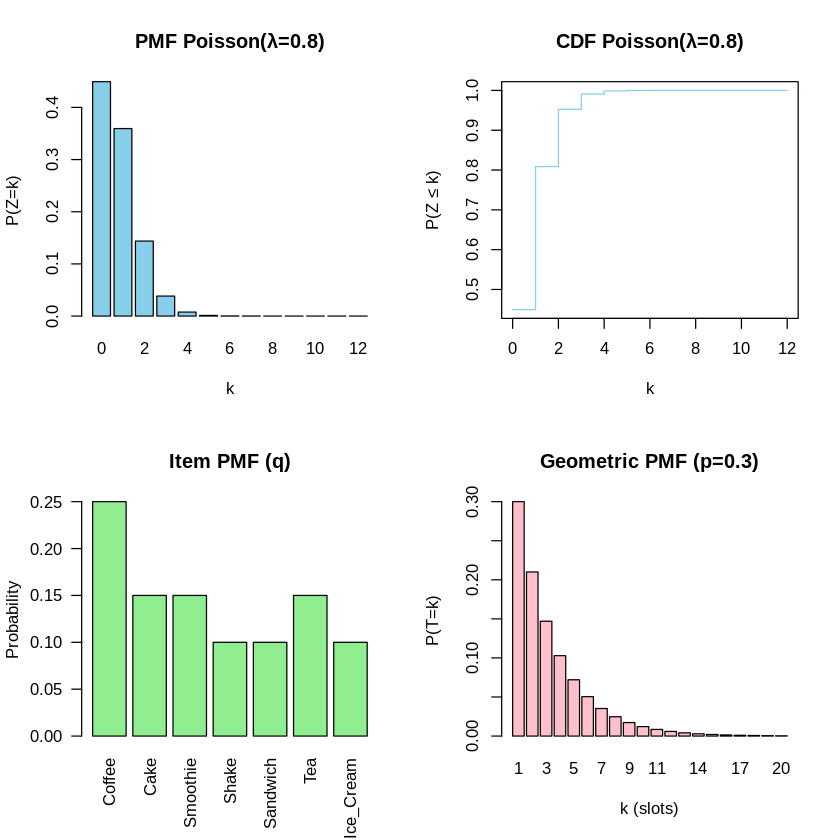

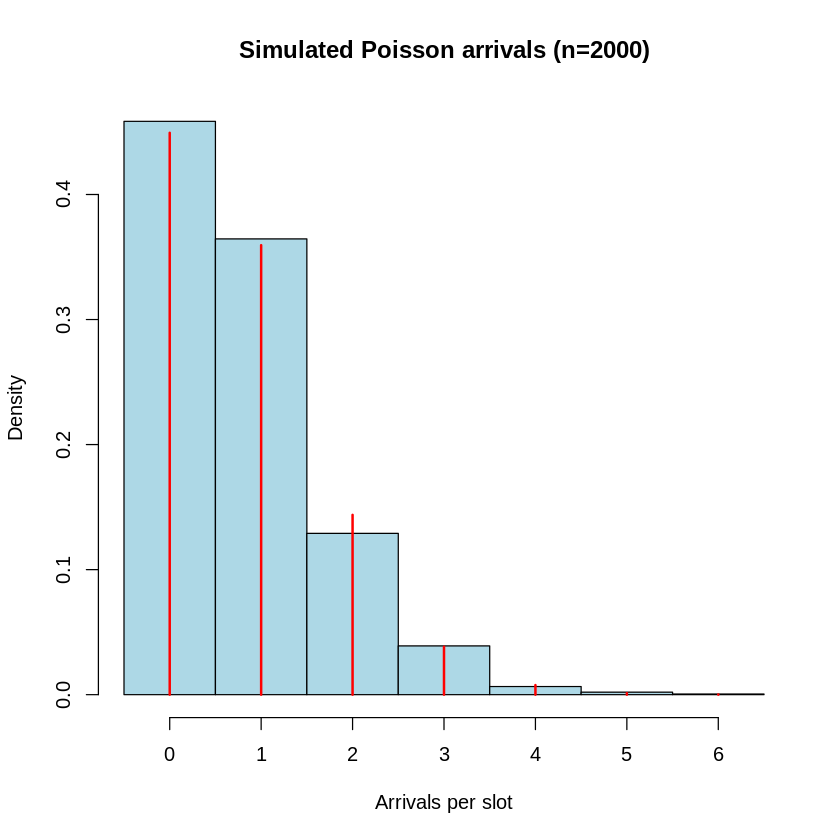

In [6]:
# Phase 1 implementation

# 1) Poisson PMF/CDF (k=0..12)
k_vals <- 0:12
pmf_Z <- dpois(k_vals, lambda_base)
cdf_Z <- ppois(k_vals, lambda_base)

poisson_table <- data.frame(k = k_vals, PMF = round(pmf_Z, 6), CDF = round(cdf_Z, 6))
kable(poisson_table, caption = "Poisson(λ=0.8) PMF and CDF (k=0..12)")

# Print mean/variance analytical
# Poisson -> mean = variance = lambda
mean_analytical <- lambda_base
variance_analytical <- lambda_base

print(paste("Analytical Mean for Poisson(lambda =", lambda_base, "Distribution:", mean_analytical))
print(paste("Analytical Variance for Poisson(lambda =", lambda_base, "Distribution:", mean_analytical))

# 2) Item PMF table
item_df <- data.frame(Item = menu_names, Prob = as.numeric(menu_q))
kable(item_df, caption = "Item PMF (categorical)")

# 3) Geometric PMF/CDF example for p=0.30 (support 1..20)
p_example <- 0.30
k_t <- 1:20
pmf_T_example <- dgeom(k_t - 1, prob = p_example)
cdf_T_example <- pgeom(k_t - 1, prob = p_example)
cat("Example: p =", p_example, " => E[T] =", round(1/p_example,6), " Var(T) =", round((1-p_example)/p_example^2,6), "\n")

# 4) Plots: PMF and CDF and simulated Poisson overlay
par(mfrow = c(2,2))
barplot(pmf_Z, names.arg = k_vals, main = "PMF Poisson(λ=0.8)", xlab = "k", ylab = "P(Z=k)", col = 'skyblue')
plot(k_vals, cdf_Z, type = "s", main = "CDF Poisson(λ=0.8)", xlab = "k", ylab = "P(Z ≤ k)", col = 'skyblue')
barplot(as.numeric(menu_q), names.arg = menu_names, las = 2, main = "Item PMF (q)", ylab = "Probability", col = 'lightgreen')
barplot(pmf_T_example, names.arg = k_t, main = paste0("Geometric PMF (p=", p_example, ")"), xlab = "k (slots)", ylab = "P(T=k)", col = 'pink')
par(mfrow = c(1,1))

# Small simulation overlay: Poisson
N <- 2000 #number of samples
sim_Z <- rpois(N, lambda = lambda_base)
hist(sim_Z, breaks = seq(-0.5, max(sim_Z)+0.5, 1), freq = FALSE, main = "Simulated Poisson arrivals (n=2000)", col = 'lightblue', xlab = "Arrivals per slot")
points(k_vals, pmf_Z, type = "h", col = "red", lwd = 2)


## Phase 2 — Expanded sampling & visualization (menu-aware)

Poisson sample: mean = 0.8125  var = 0.8378 





Table: Empirical item selection (N=2000)

|Item      | Count| Proportion|
|:---------|-----:|----------:|
|Coffee    |   529|     0.2645|
|Cake      |   318|     0.1590|
|Smoothie  |   299|     0.1495|
|Shake     |   181|     0.0905|
|Sandwich  |   196|     0.0980|
|Tea       |   292|     0.1460|
|Ice_Cream |   185|     0.0925|

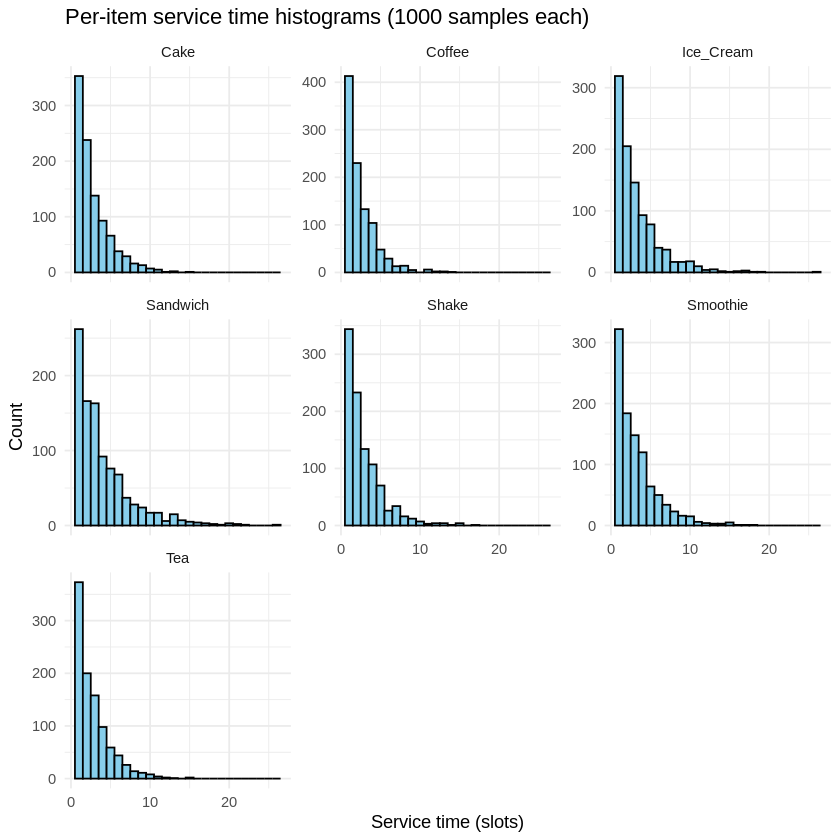

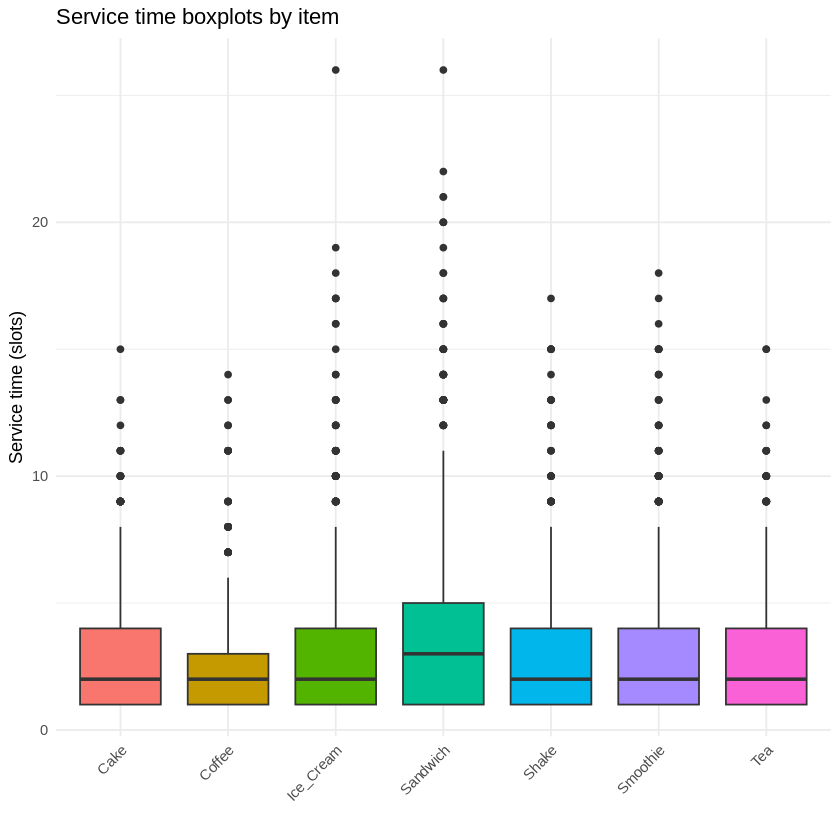

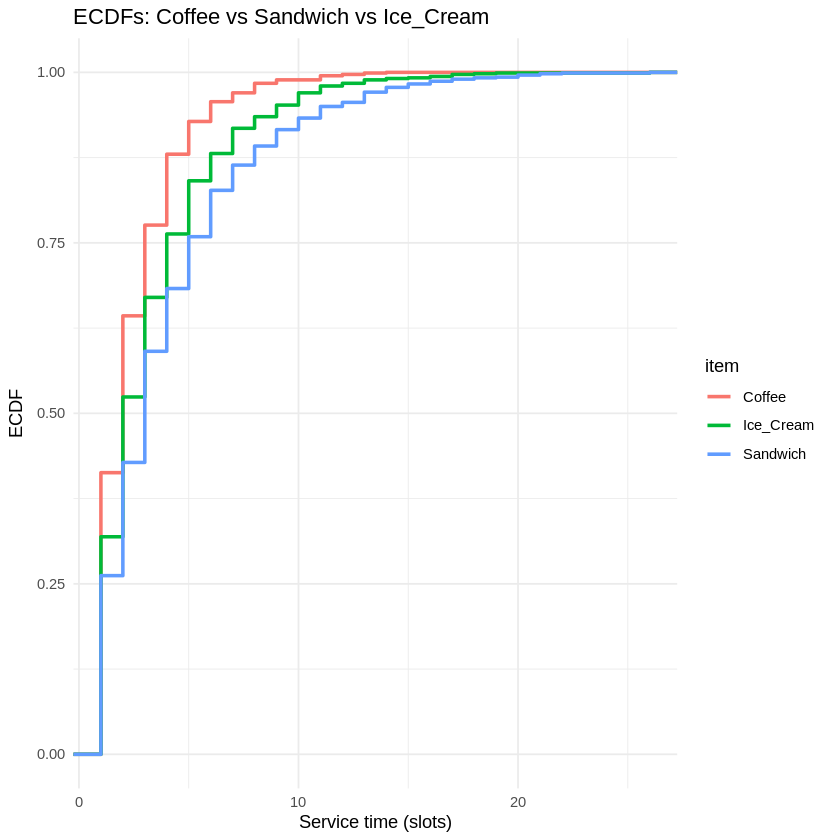

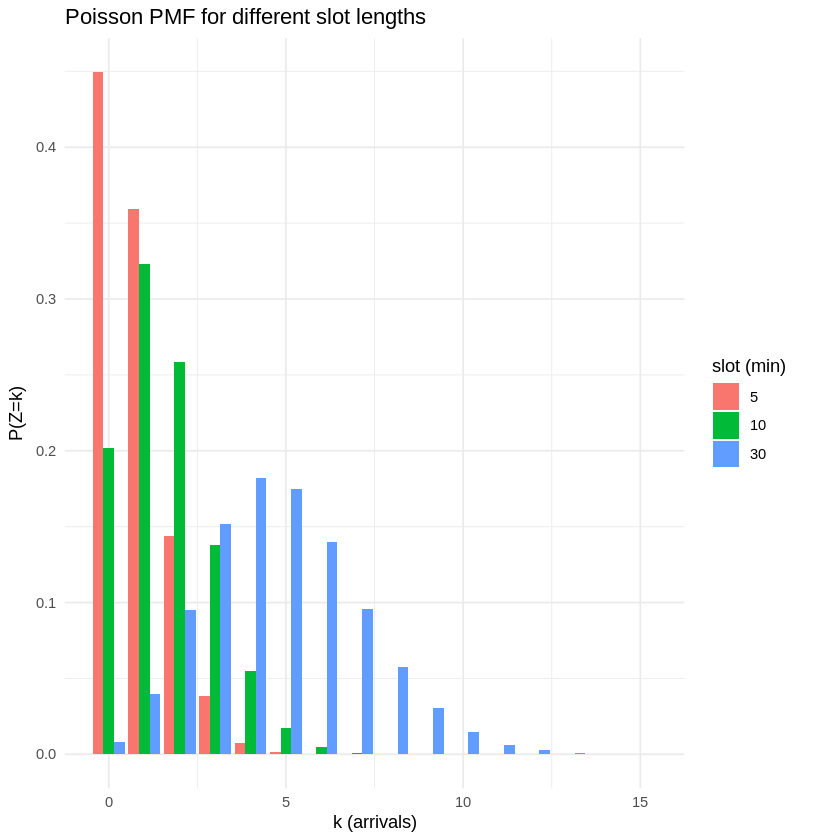

In [9]:
# Phase 2 implementation

set.seed(2025)
N <- 2000

# 1) Poisson samples
pois_sample <- rpois(N, lambda_base)
cat("Poisson sample: mean =", round(mean(pois_sample),4), " var =", round(var(pois_sample),4), "\n\n")

# 2) Item samples
items_sample <- sample(menu_names, size = N, replace = TRUE, prob = menu_q)
item_counts <- table(factor(items_sample, levels = menu_names))
kable(data.frame(Item = names(item_counts), Count = as.integer(item_counts), Proportion = round(as.numeric(item_counts)/N,4)),
      caption = paste0("Empirical item selection (N=", N, ")"))

# 3) Per-item geometric samples (1000 each)
samples_per_item <- 1000
service_samples <- lapply(menu_p, function(pp) rgeom(samples_per_item, prob = pp) + 1)
names(service_samples) <- names(menu_p)

# Prepare data frame for plotting
service_df <- data.frame(time = unlist(service_samples), item = rep(names(menu_p), each = samples_per_item))

# Histograms: facet by item
ggplot(service_df, aes(x = time)) +
  geom_histogram(binwidth = 1, boundary = 0.5, color = "black", fill = "skyblue") +
  facet_wrap(~item, scales = "free_y") +
  labs(title = "Per-item service time histograms (1000 samples each)", x = "Service time (slots)", y = "Count") +
  theme_minimal()

# Boxplots of service times
ggplot(service_df, aes(x = item, y = time, fill = item)) +
  geom_boxplot() + labs(title = "Service time boxplots by item", x = "", y = "Service time (slots)") +
  theme_minimal() + theme(axis.text.x = element_text(angle = 45, hjust = 1)) + guides(fill = "none")

# ECDF overlays for Coffee, Sandwich, Dessert
ggplot(filter(service_df, item %in% c("Coffee","Sandwich","Ice_Cream")), aes(x = time, color = item)) +
  stat_ecdf(size = 1) +
  labs(title = "ECDFs: Coffee vs Sandwich vs Ice_Cream", x = "Service time (slots)", y = "ECDF") +
  theme_minimal()

# 4) Poisson PMF for slot lengths (5,10,30 minutes)
slot_minutes <- c(5,10,30)
lambda_slots <- lambda_base * (slot_minutes / 5)
k_max <- 0:15
poisson_pmf_df <- data.frame()
for (i in seq_along(slot_minutes)) {
  pmf_values <- dpois(k_max, lambda = lambda_slots[i])

  temp_df <- data.frame(
    slot = slot_minutes[i],
    k = k_max,
    pmf = pmf_values
  )

  poisson_pmf_df <- rbind(poisson_pmf_df, temp_df)
}
ggplot(poisson_pmf_df, aes(x = k, y = pmf, fill = factor(slot))) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Poisson PMF for different slot lengths", x = "k (arrivals)", y = "P(Z=k)", fill = "slot (min)") +
  theme_minimal()


## Phase 3 — Per-item analytic quantities and bottleneck identification



Table: Menu: q, p, E[T], Var[T]

|Item      |    q|    p|      E_T|     Var_T|
|:---------|----:|----:|--------:|---------:|
|Coffee    | 0.25| 0.40| 2.500000|  3.750000|
|Cake      | 0.15| 0.35| 2.857143|  5.306122|
|Smoothie  | 0.15| 0.30| 3.333333|  7.777778|
|Shake     | 0.10| 0.35| 2.857143|  5.306122|
|Sandwich  | 0.10| 0.25| 4.000000| 12.000000|
|Tea       | 0.15| 0.35| 2.857143|  5.306122|
|Ice_Cream | 0.10| 0.30| 3.333333|  7.777778|

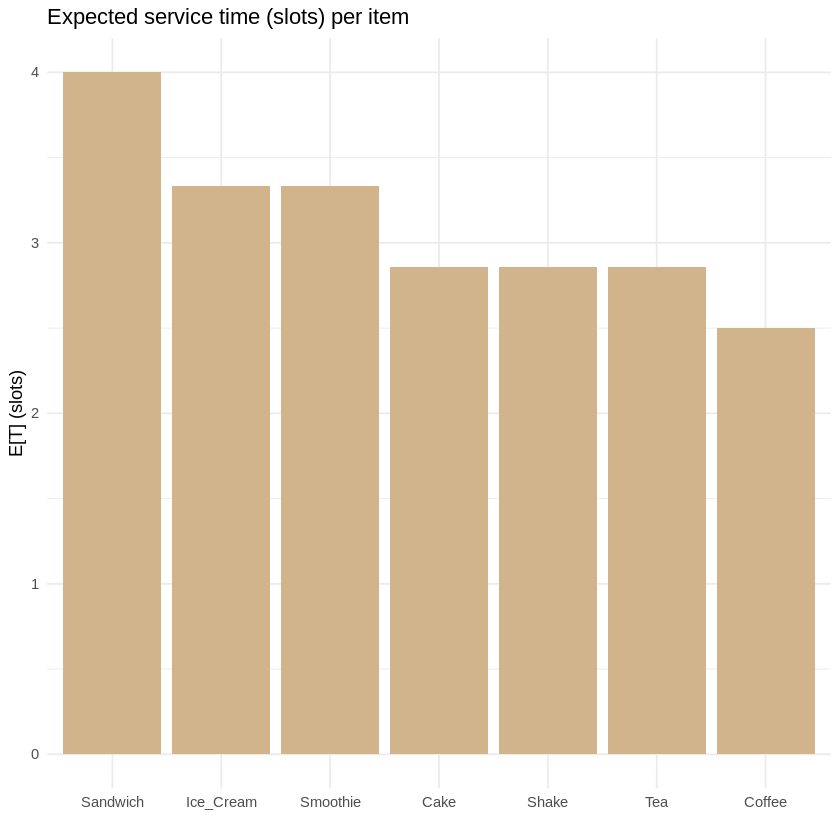

In [10]:
# Phase 3 implementation

# Compute E[T] and Var[T]
menu_df <- data.frame(Item = names(menu_p), q = as.numeric(menu_q), p = as.numeric(menu_p), stringsAsFactors = FALSE)
menu_df$E_T <- 1 / menu_df$p
menu_df$Var_T <- (1 - menu_df$p) / (menu_df$p)^2
kable(menu_df, caption = "Menu: q, p, E[T], Var[T]")

# Barplot of expected times
ggplot(menu_df, aes(x = reorder(Item, -E_T), y = E_T)) +
  geom_bar(stat = "identity", fill = "tan") +
  labs(title = "Expected service time (slots) per item", x = "", y = "E[T] (slots)") +
  theme_minimal()


## Phase 4 — Detailed (item-aware) FIFO queue simulation

### Objectives
In this phase, we extend the discrete-time queue model to include **item-level details** and analyze system behavior under different arrival rates.  
Customers arrive according to a Poisson($\lambda$) process per slot. Each new arrival selects one menu item based on categorical probabilities $q_i$.  

Each ordered item requires a random geometric number of slots $T_i \sim \text{Geom}(p_i)$ to complete service (where $p_i$ is the per-slot success probability).  
During each slot:
- Two base servers are always active.
- A third server is **activated dynamically** when the queue length before service exceeds a threshold $h$ beyond the base servers:  
  $$
  s_t =
  \begin{cases}
  2, & \text{if } Q_{t-1} - 2 < h,\\
  3, & \text{otherwise.}
  \end{cases}
  $$

Each active server attempts to serve the *front* customer using one Bernoulli trial with the relevant $p_i$.  
If successful, the front item departs (service completed). If unsuccessful, the customer remains for the next slot (other servers may still attempt it within the same slot).

We’ll simulate three different load scenarios:

| Scenario | $\lambda$ | Description |
|-----------|------------|-------------|
| Low Load | 0.4 | Sparse arrivals, queue often empty |
| Base Load | 0.8 | Moderate flow, queue stabilized |
| High Load | 1.5 | Heavy traffic, possible buildup |


In [11]:
# Phase 4 implementation

# Ensure required packages are available
library(ggplot2)
library(dplyr)
library(tidyr)

# Function for detailed queue simulation
simulate_cafe_detailed <- function(lambda,
                                   num_slots = 2000,
                                   menu_q_in,
                                   menu_p_in,
                                   base_servers = 2,
                                   activation_threshold = 4,
                                   verbose = FALSE) {
  if (is.null(names(menu_q_in)) || is.null(names(menu_p_in))) {
    stop("menu_q_in and menu_p_in must be named vectors with identical names.")
  }

  item_names <- names(menu_q_in)
  n_items <- length(item_names)

  Q <- integer(num_slots + 1)
  queue_list <- vector("list", num_slots + 1)
  queue_list[[1]] <- character(0)
  third_active <- logical(num_slots)
  comp_mat <- matrix(0, nrow = num_slots + 1, ncol = n_items)
  colnames(comp_mat) <- item_names

  for (t in 1:num_slots) {
    # --- Arrivals ---

    num_arrivals <- rpois(1, lambda)
    if (num_arrivals > 0) {
      new_items <- sample(item_names, size = num_arrivals, replace = TRUE, prob = menu_q_in)
      queue_list[[t]] <- c(queue_list[[t]], new_items)
    }
    current_queue <- queue_list[[t]]
    Q[t] <- length(current_queue)

    # --- Servers ---

    active_servers <- base_servers
    if (Q[t] - base_servers >= activation_threshold) {
      active_servers <- base_servers + 1
      third_active[t] <- TRUE
    }

    # --- Service attempts ---

    remaining <- current_queue

    if (length(remaining) > 0) {
      num_to_serve <- min(active_servers, length(remaining))
      served_positions <- logical(length(remaining))

      for (i in 1:num_to_serve) {
        item <- remaining[i]
        success <- runif(1) < menu_p_in[item]
        if (success)
          served_positions[i] <- TRUE
      }

      if (any(served_positions))
        remaining <- remaining[!served_positions]
    }

    queue_list[[t + 1]] <- remaining
    Q[t + 1] <- length(remaining)

    if (length(remaining) > 0) {
      comp_mat[t + 1, ] <- as.integer(table(factor(remaining, levels = item_names)))
    }
  }

  list(Q = Q,
       queue = queue_list,
       comp = comp_mat,
       third_active = third_active,
       lambda = lambda,
       num_slots = num_slots)
}

# ---- Run all three scenarios ----
set.seed(2025)
res_low <- simulate_cafe_detailed(lambda = 0.4, num_slots = 2000,
                                  menu_q_in = menu_q, menu_p_in = menu_p,
                                  base_servers = base_servers,
                                  activation_threshold = activation_threshold_default)

res_base <- simulate_cafe_detailed(lambda = 0.8, num_slots = 2000,
                                   menu_q_in = menu_q, menu_p_in = menu_p,
                                   base_servers = base_servers,
                                   activation_threshold = activation_threshold_default)

res_high <- simulate_cafe_detailed(lambda = 1.5, num_slots = 2000,
                                   menu_q_in = menu_q, menu_p_in = menu_p,
                                   base_servers = base_servers,
                                   activation_threshold = activation_threshold_default)

# ---- Summaries ----
summarize_results <- function(res) {
  Q <- res$Q
  c(mean_Q = mean(Q),
    var_Q = var(Q),
    P_Q0 = mean(Q == 0),
    P_third = mean(res$third_active))
}

summary_table <- rbind(
  Low = summarize_results(res_low),
  Base = summarize_results(res_base),
  High = summarize_results(res_high)
)

round(summary_table, 4)

,mean_Q,var_Q,P_Q0,P_third
Low,1.5822,2.1924,0.2499,0.0195
Base,6.6362,16.5746,0.0140,0.5370
High,523.6842,82489.0142,0.0010,0.9980


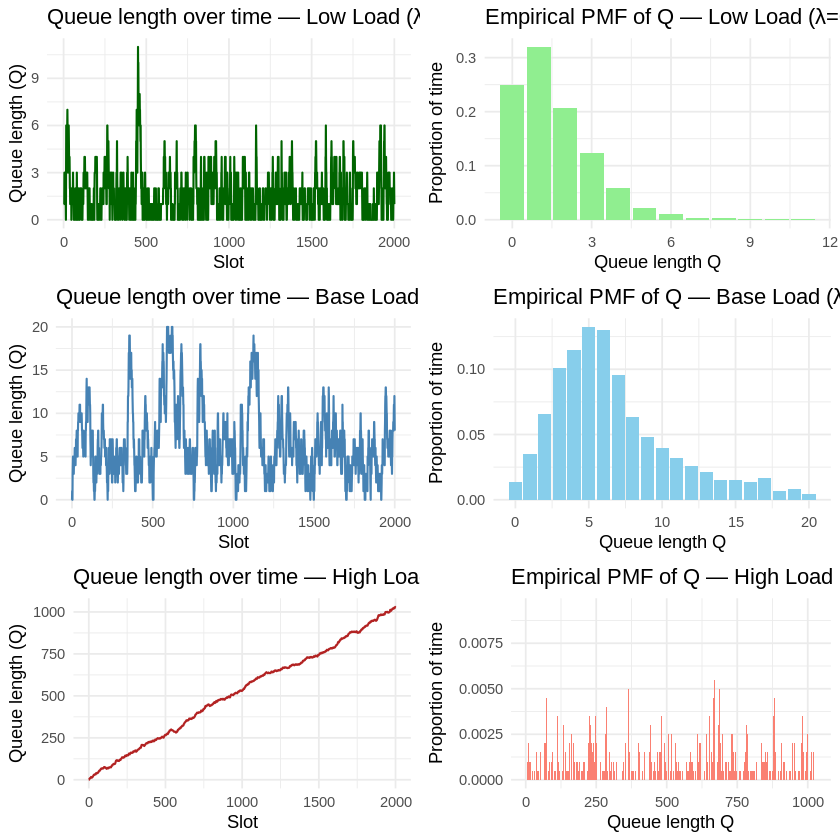

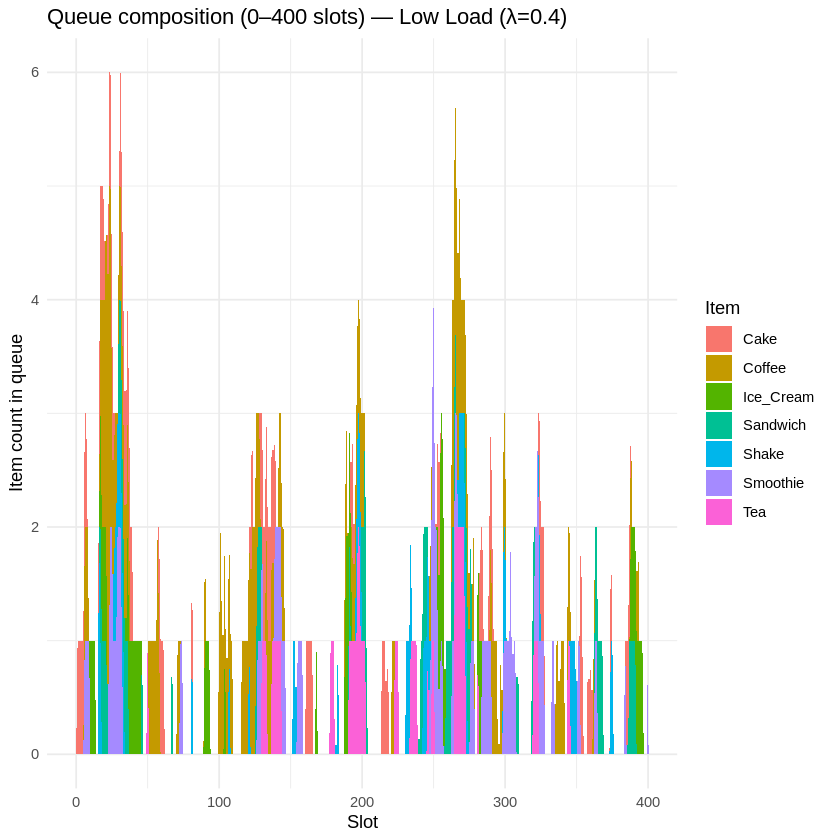

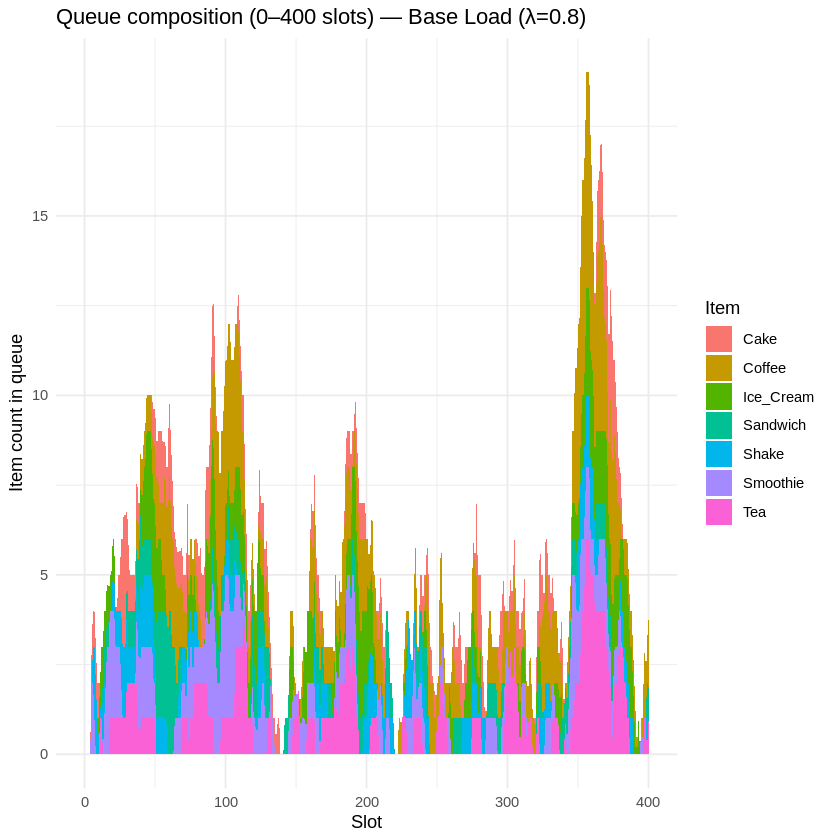

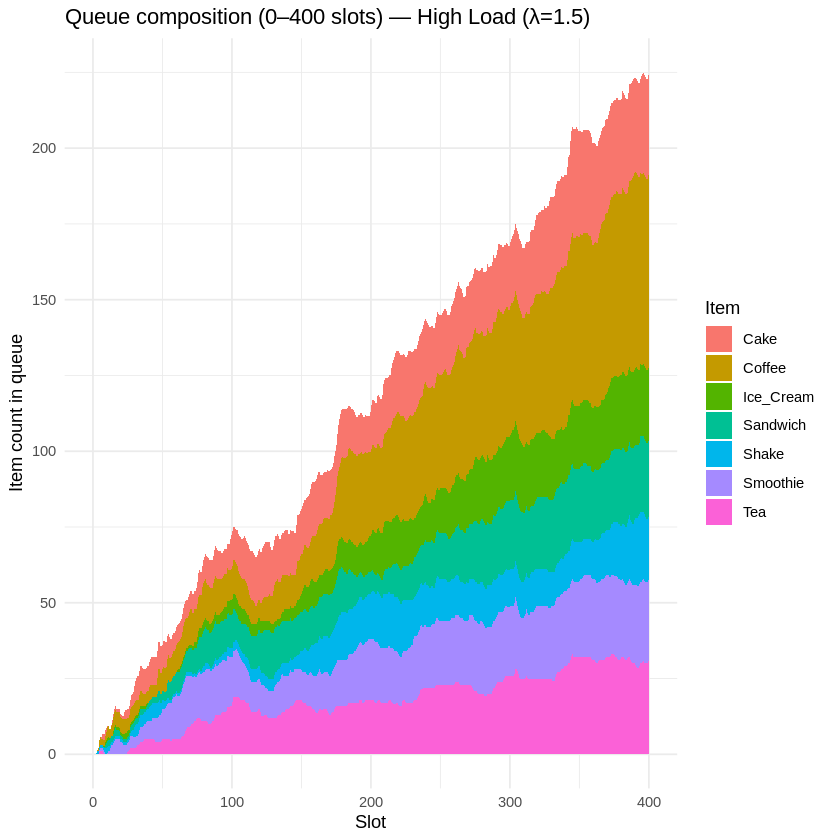

In [12]:
# Visualization and Analysis

plot_Q_series <- function(res, title_label, color = "steelblue") {
  df <- data.frame(slot = 0:res$num_slots, Q = res$Q)
  ggplot(df, aes(x = slot, y = Q)) +
    geom_line(color = color, linewidth = 0.6) +
    labs(title = paste("Queue length over time —", title_label),
         x = "Slot", y = "Queue length (Q)") +
    theme_minimal()
}

plot_Q_pmf <- function(res, title_label, fill_color = "skyblue") {
  df <- data.frame(Q = res$Q)
  pmf <- df %>% count(Q) %>% mutate(prop = n / sum(n))
  ggplot(pmf, aes(x = Q, y = prop)) +
    geom_col(fill = fill_color) +
    labs(title = paste("Empirical PMF of Q —", title_label),
         x = "Queue length Q", y = "Proportion of time") +
    theme_minimal()
}

plot_composition <- function(res, title_label) {
  comp_first <- as.data.frame(res$comp[1:401, , drop = FALSE])
  comp_first$slot <- 0:400
  comp_long <- pivot_longer(comp_first, cols = -slot, names_to = "Item", values_to = "Count")
  ggplot(comp_long, aes(x = slot, y = Count, fill = Item)) +
    geom_area() +
    labs(title = paste("Queue composition (0–400 slots) —", title_label),
         x = "Slot", y = "Item count in queue") +
    theme_minimal()
}

# Generate plots
p_low <- plot_Q_series(res_low, "Low Load (λ=0.4)", "darkgreen")
p_low_pmf <- plot_Q_pmf(res_low, "Low Load (λ=0.4)", "lightgreen")
p_low_comp <- plot_composition(res_low, "Low Load (λ=0.4)")

p_base <- plot_Q_series(res_base, "Base Load (λ=0.8)")
p_base_pmf <- plot_Q_pmf(res_base, "Base Load (λ=0.8)")
p_base_comp <- plot_composition(res_base, "Base Load (λ=0.8)")

p_high <- plot_Q_series(res_high, "High Load (λ=1.5)", "firebrick")
p_high_pmf <- plot_Q_pmf(res_high, "High Load (λ=1.5)", "salmon")
p_high_comp <- plot_composition(res_high, "High Load (λ=1.5)")

# Arrange outputs
grid.arrange(p_low, p_low_pmf, p_base, p_base_pmf, p_high, p_high_pmf, ncol = 2)
print(p_low_comp)
print(p_base_comp)
print(p_high_comp)


## Phase 5 — Sensitivity and Stability Analysis

### Objectives
In this phase, we perform a **systematic sensitivity study** on the arrival rate $\lambda$ to explore the boundaries of stability and system performance.  
Using the detailed FIFO queue simulator from Phase 4, we vary $\lambda$ across a broad range and measure how the queue behaves statistically.

In [13]:
# Phase 5 implementation

# ---- SETTINGS ----
lambda_grid <- seq(0.2, 1.5, by = 0.1)
num_slots   <- 2000
base_servers_default <- 2
activation_threshold_default <- 4
stability_threshold <- 0.8 * 3  # 2.4

# Check simulate_queue exists
if (!exists("simulate_queue") && !exists("simulate_cafe_detailed")) {
  stop("No simulate_queue or simulate_cafe_detailed function found in the workspace. Please run Phase 4 code first.")
}

# Choose the function available
sim_fun <- if (exists("simulate_queue")) get("simulate_queue") else get("simulate_cafe_detailed")

# Inspect its formal argument names and prepare mapping
sim_formals <- names(formals(sim_fun))

# Build args list using names present in the function
build_sim_args <- function(lambda_val, num_slots_val, menu_q_val, menu_p_val,
                           base_servers_val, activation_threshold_val) {
  args <- list()
  # possible names we want to set (common variants)
  wanted <- list(
    lambda = lambda_val, lambda_in = lambda_val, lambda_val = lambda_val,
    num_slots = num_slots_val, num_slots_in = num_slots_val, n = num_slots_val,
    menu_q = menu_q_val, menu_q_in = menu_q_val, menu_qs = menu_q_val,
    menu_p = menu_p_val, menu_p_in = menu_p_val, menu_ps = menu_p_val,
    base_servers = base_servers_val, base_servers_in = base_servers_val,
    activation_threshold = activation_threshold_val, activation_threshold_in = activation_threshold_val,
    h = activation_threshold_val, threshold_h = activation_threshold_val, thr = activation_threshold_val
  )
  for (nm in names(wanted)) {
    if (nm %in% sim_formals) args[[nm]] <- wanted[[nm]]
  }
  args
}

# If build_sim_args returns an empty list, we'll attempt a fallback positional call:
can_call_by_name <- length(build_sim_args(0.2, num_slots, menu_q, menu_p, base_servers_default, activation_threshold_default)) > 0

# Storage
results <- data.frame(lambda = lambda_grid,
                      mean_Q = NA_real_, var_Q = NA_real_,
                      P_Q0 = NA_real_, P_third = NA_real_, stringsAsFactors = FALSE)

# Simulation runner that uses do.call with the discovered argument names
run_sim <- function(lambda_val) {
  args <- build_sim_args(lambda_val, num_slots, menu_q, menu_p,
                         base_servers_default, activation_threshold_default)
  # If no named args matched, try a positional call with a few common signatures
  if (length(args) == 0) {
    # We'll attempt option 1 then 2; use tryCatch to return informative errors.
    try_pos1 <- try(do.call(sim_fun, list(lambda, num_slots, menu_q, menu_p, base_servers_default, activation_threshold_default)), silent = TRUE)
    if (!inherits(try_pos1, "try-error")) return(try_pos1)
    try_pos2 <- try(do.call(sim_fun, list(lambda, menu_q, menu_p, num_slots, base_servers_default, activation_threshold_default)), silent = TRUE)
    if (!inherits(try_pos2, "try-error")) return(try_pos2)
    stop("Unable to call the simulator: it has an unexpected signature. Inspect formals(simulate_queue).")
  } else {
    # call by name
    out <- try(do.call(sim_fun, args = args), silent = TRUE)
    if (inherits(out, "try-error")) {
      stop("Simulator call failed when called with matched argument names: ", out)
    }
    return(out)
  }
}


for (i in seq_along(lambda_grid)) {
  lam <- lambda_grid[i]
  sim_out <- run_sim(lam)

  # Try to find Q series and third_active logically.
  if (is.list(sim_out)) {
    # heuristics to find Q vector:
    Q_candidates <- c("Q", "queue_length", "queue", "q_length", "q")
    Q_series <- NULL
    for (nm in Q_candidates) {
      if (!is.null(sim_out[[nm]])) {
        Q_series <- sim_out[[nm]]
        break
      }
    }
    # if not found, check if sim_out is data.frame with Q column or numeric vector
    if (is.null(Q_series)) {
      if (is.data.frame(sim_out) && "Q" %in% colnames(sim_out)) Q_series <- sim_out$Q
      else if (is.numeric(sim_out) && length(sim_out) > 1) Q_series <- sim_out
    }
    # third active
    third_candidates <- c("third_active", "third", "thirdActive", "thirdActiveFlag")
    third_active <- NULL
    for (nm in third_candidates) {
      if (!is.null(sim_out[[nm]])) {
        third_active <- sim_out[[nm]]
        break
      }
    }
    # fallback: if sim_out$data.frame exists with column 'third' or 'third_active'
    if (is.null(third_active) && is.data.frame(sim_out)) {
      if ("third_active" %in% colnames(sim_out)) third_active <- sim_out$third_active
      else if ("third" %in% colnames(sim_out)) third_active <- sim_out$third
    }
  } else if (is.numeric(sim_out)) {
      Q_series <- sim_out
      third_active <- rep(FALSE, length(Q_series))
  } else {
    stop("Unexpected simulator output type; expected list/data.frame/numeric vector.")
  }

  if (is.null(Q_series)) stop("Could not locate queue length series in simulator output for λ = ", lam)
  if (is.null(third_active)) third_active <- rep(FALSE, length(Q_series))

  # Normalize types
  Q_series <- as.numeric(Q_series)
  third_active <- as.logical(third_active)
  # compute metrics
  results$mean_Q[i] <- mean(Q_series, na.rm = TRUE)
  results$var_Q[i]  <- var(Q_series, na.rm = TRUE)
  results$P_Q0[i]   <- mean(Q_series == 0, na.rm = TRUE)
  results$P_third[i] <- mean(third_active, na.rm = TRUE)

  cat(sprintf("λ = %.1f | E[Q]=%.3f | Var(Q)=%.3f | P(Q=0)=%.3f | P(third)=%.3f\n",
              lam, results$mean_Q[i], results$var_Q[i], results$P_Q0[i], results$P_third[i]))
}

# Stability label and lambda_stab
results$Stable <- ifelse(results$mean_Q < stability_threshold, "Stable", "Unstable")
lambda_stab <- if (any(results$Stable == "Unstable")) min(results$lambda[results$Stable == "Unstable"]) else NA_real_

λ = 0.2 | E[Q]=0.589 | Var(Q)=0.668 | P(Q=0)=0.577 | P(third)=0.000
λ = 0.3 | E[Q]=1.071 | Var(Q)=1.273 | P(Q=0)=0.373 | P(third)=0.004
λ = 0.4 | E[Q]=1.526 | Var(Q)=1.984 | P(Q=0)=0.266 | P(third)=0.011
λ = 0.5 | E[Q]=2.175 | Var(Q)=3.537 | P(Q=0)=0.192 | P(third)=0.061
λ = 0.6 | E[Q]=3.398 | Var(Q)=7.591 | P(Q=0)=0.104 | P(third)=0.172
λ = 0.7 | E[Q]=4.287 | Var(Q)=7.505 | P(Q=0)=0.047 | P(third)=0.287
λ = 0.8 | E[Q]=6.271 | Var(Q)=22.715 | P(Q=0)=0.024 | P(third)=0.454
λ = 0.9 | E[Q]=10.019 | Var(Q)=34.873 | P(Q=0)=0.006 | P(third)=0.765
λ = 1.0 | E[Q]=78.065 | Var(Q)=1131.023 | P(Q=0)=0.000 | P(third)=0.988
λ = 1.1 | E[Q]=125.826 | Var(Q)=1730.198 | P(Q=0)=0.000 | P(third)=0.996
λ = 1.2 | E[Q]=133.011 | Var(Q)=8811.758 | P(Q=0)=0.000 | P(third)=0.996
λ = 1.3 | E[Q]=321.592 | Var(Q)=37284.179 | P(Q=0)=0.000 | P(third)=0.999
λ = 1.4 | E[Q]=431.621 | Var(Q)=64651.598 | P(Q=0)=0.000 | P(third)=0.996
λ = 1.5 | E[Q]=531.604 | Var(Q)=88366.576 | P(Q=0)=0.000 | P(third)=0.999


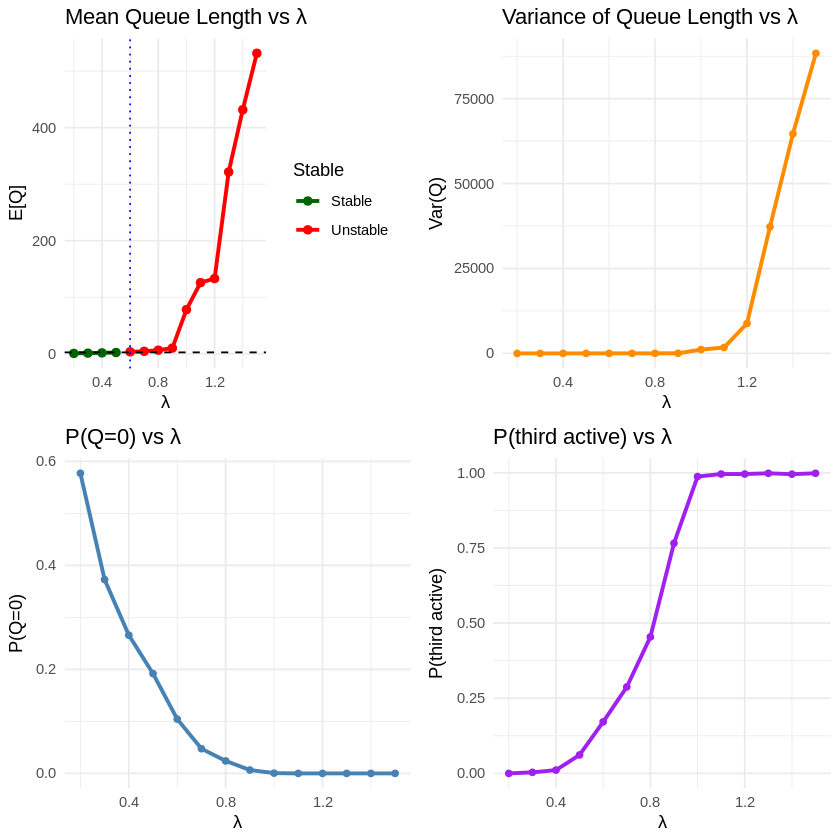


Empirical stability transition at lambda_stab ≈ 0.6 


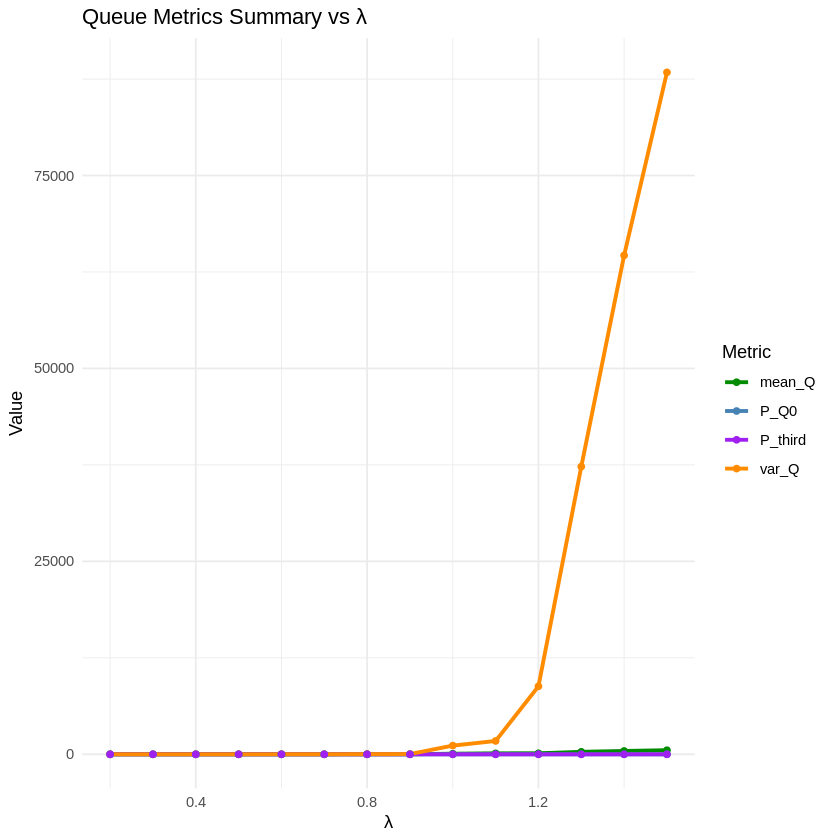

In [14]:
# Visualization and Analysis

library(ggplot2); library(gridExtra); library(tidyr)

p1 <- ggplot(results, aes(lambda, mean_Q, color = Stable)) +
  geom_line(size = 1.1) + geom_point(size = 2) +
  geom_hline(yintercept = stability_threshold, linetype = "dashed") +
  { if (!is.na(lambda_stab)) geom_vline(xintercept = lambda_stab, linetype = "dotted", color = "blue") } +
  scale_color_manual(values = c("Stable" = "darkgreen", "Unstable" = "red")) +
  labs(title = "Mean Queue Length vs λ", y = "E[Q]", x = "λ") +
  theme_minimal()

p2 <- ggplot(results, aes(lambda, var_Q)) +
  geom_line(color = "darkorange", size = 1.1) + geom_point(color = "darkorange") +
  labs(title = "Variance of Queue Length vs λ", y = "Var(Q)", x = "λ") + theme_minimal()

p3 <- ggplot(results, aes(lambda, P_Q0)) +
  geom_line(color = "steelblue", size = 1.1) + geom_point(color = "steelblue") +
  labs(title = "P(Q=0) vs λ", y = "P(Q=0)", x = "λ") + theme_minimal()

p4 <- ggplot(results, aes(lambda, P_third)) +
  geom_line(color = "purple", size = 1.1) + geom_point(color = "purple") +
  labs(title = "P(third active) vs λ", y = "P(third active)", x = "λ") + theme_minimal()

grid.arrange(p1, p2, p3, p4, ncol = 2)

results_long <- pivot_longer(results, cols = c(mean_Q, var_Q, P_Q0, P_third),
                             names_to = "Metric", values_to = "Value")
ggplot(results_long, aes(lambda, Value, color = Metric)) +
  geom_line(size = 1.1) + geom_point() +
  scale_color_manual(values = c("mean_Q" = "green4", "var_Q" = "darkorange",
                                "P_Q0" = "steelblue", "P_third" = "purple")) +
  labs(title = "Queue Metrics Summary vs λ", x = "λ", y = "Value") +
  theme_minimal()


# Print lambda_stab message
if (!is.na(lambda_stab)) {
  cat("\nEmpirical stability transition at lambda_stab ≈", lambda_stab, "\n")
} else {
  cat("\nNo instability observed in the scanned λ grid (lambda_stab = NA)\n")
}


## Phase 6 — Sensitivity to Dynamic Activation Threshold $h$

### Objectives

In this phase, we explore how the **dynamic server activation threshold** $h$ affects queue stability and performance. Recall that the third server activates when $Q_{t-1} - 2 \ge h$.

In [15]:
# Phase 6 implementation

h_grid <- 1:8
lambda_val <- 0.8
num_slots <- 2000
base_servers <- 2

results_h <- data.frame(h = h_grid,
                        mean_Q = NA_real_,
                        var_Q = NA_real_,
                        P_Q0 = NA_real_,
                        P_third = NA_real_,
                        stringsAsFactors = FALSE)


simulate_queue <- function(lambda, num_slots, base_servers = 2, h = 4,
                           menu_q, menu_p) {
  # ---- Initialization ----
  Q_series <- numeric(num_slots)
  third_active <- logical(num_slots)
  queue <- character(0)

  for (t in 1:num_slots) {
    arrivals <- rpois(1, lambda)
    if (arrivals > 0) {
      new_items <- sample(names(menu_q), arrivals, TRUE, menu_q)
      queue <- c(queue, new_items)
    }

    # --- Dynamic server activation ---
    active_servers <- ifelse(length(queue) - base_servers >= h, 3, 2)
    third_active[t] <- (active_servers == 3)

    # --- Service step ---
    served <- 0
    if (length(queue) > 0) {
      for (s in 1:active_servers) {
        if (length(queue) == 0) break
        item <- queue[1]
        if (runif(1) < menu_p[item]) {
          queue <- queue[-1]
          served <- served + 1
        } else {
          queue <- c(queue[-1], item)
        }
      }
    }
    Q_series[t] <- length(queue)
  }

  list(Q_series = Q_series, third_active = third_active)
}


# Run simulations for each h
for (i in seq_along(h_grid)) {
  h_val <- h_grid[i]
  sim_out <- simulate_queue(lambda = lambda_val,
                            num_slots = num_slots,
                            base_servers = base_servers,
                            h = h_val,
                            menu_q = menu_q,
                            menu_p = menu_p)

  Q_series <- sim_out$Q_series
  results_h$mean_Q[i] <- mean(Q_series)
  results_h$var_Q[i] <- var(Q_series)
  results_h$P_Q0[i] <- mean(Q_series == 0)
  results_h$P_third[i] <- mean(sim_out$third_active)

  cat(sprintf("h=%d | E[Q]=%.3f | Var(Q)=%.3f | P(Q=0)=%.3f | P(third)=%.3f\n",
              h_val, results_h$mean_Q[i], results_h$var_Q[i],
              results_h$P_Q0[i], results_h$P_third[i]))
}

results_h$Stable <- ifelse(results_h$mean_Q < 2.4, "Stable", "Unstable")


h=1 | E[Q]=3.829 | Var(Q)=11.800 | P(Q=0)=0.165 | P(third)=0.668
h=2 | E[Q]=5.337 | Var(Q)=21.758 | P(Q=0)=0.095 | P(third)=0.657
h=3 | E[Q]=3.829 | Var(Q)=9.774 | P(Q=0)=0.142 | P(third)=0.443
h=4 | E[Q]=6.415 | Var(Q)=22.572 | P(Q=0)=0.059 | P(third)=0.557
h=5 | E[Q]=6.181 | Var(Q)=14.147 | P(Q=0)=0.051 | P(third)=0.493
h=6 | E[Q]=7.218 | Var(Q)=27.770 | P(Q=0)=0.046 | P(third)=0.462
h=7 | E[Q]=7.059 | Var(Q)=13.652 | P(Q=0)=0.025 | P(third)=0.373
h=8 | E[Q]=7.639 | Var(Q)=13.233 | P(Q=0)=0.030 | P(third)=0.399


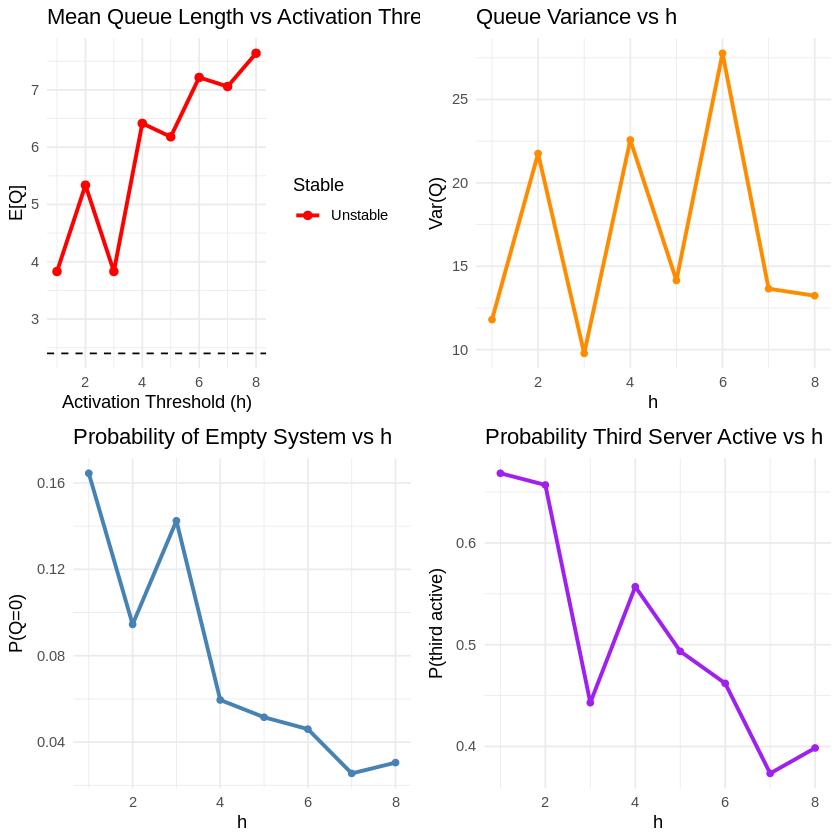

In [16]:
# Visualization and Analysis

library(ggplot2)
library(gridExtra)
library(tidyr)

p1 <- ggplot(results_h, aes(h, mean_Q, color = Stable)) +
  geom_line(size=1.1) + geom_point(size=2) +
  geom_hline(yintercept=2.4, linetype="dashed") +
  labs(title="Mean Queue Length vs Activation Threshold h",
       x="Activation Threshold (h)", y="E[Q]") +
  scale_color_manual(values=c("Stable"="darkgreen","Unstable"="red")) +
  theme_minimal()

p2 <- ggplot(results_h, aes(h, var_Q)) +
  geom_line(color="darkorange", size=1.1) + geom_point(color="darkorange") +
  labs(title="Queue Variance vs h", x="h", y="Var(Q)") +
  theme_minimal()

p3 <- ggplot(results_h, aes(h, P_Q0)) +
  geom_line(color="steelblue", size=1.1) + geom_point(color="steelblue") +
  labs(title="Probability of Empty System vs h", x="h", y="P(Q=0)") +
  theme_minimal()

p4 <- ggplot(results_h, aes(h, P_third)) +
  geom_line(color="purple", size=1.1) + geom_point(color="purple") +
  labs(title="Probability Third Server Active vs h", x="h", y="P(third active)") +
  theme_minimal()

grid.arrange(p1,p2,p3,p4,ncol=2)

## Phase 7 — Joint Sensitivity Analysis on \(\lambda\) and \(h\)

### Objectives
In this final phase, we analyze the **joint effect** of arrival rate \(\lambda\) and activation threshold \(h\) on system stability.  
This phase produces a **2D stability map** indicating regions where the queue remains under control.

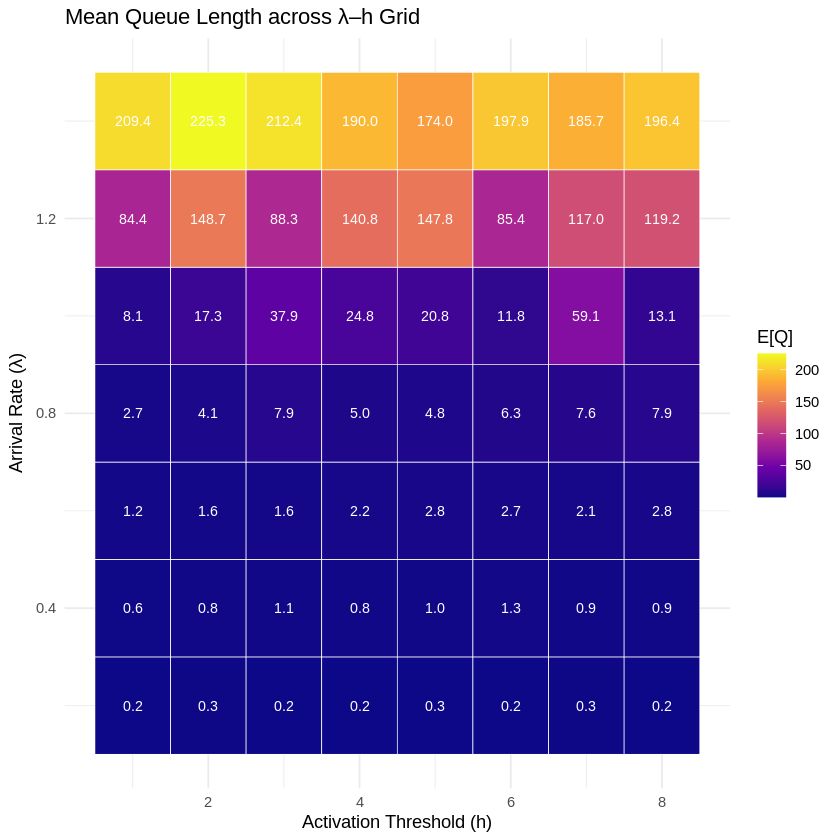

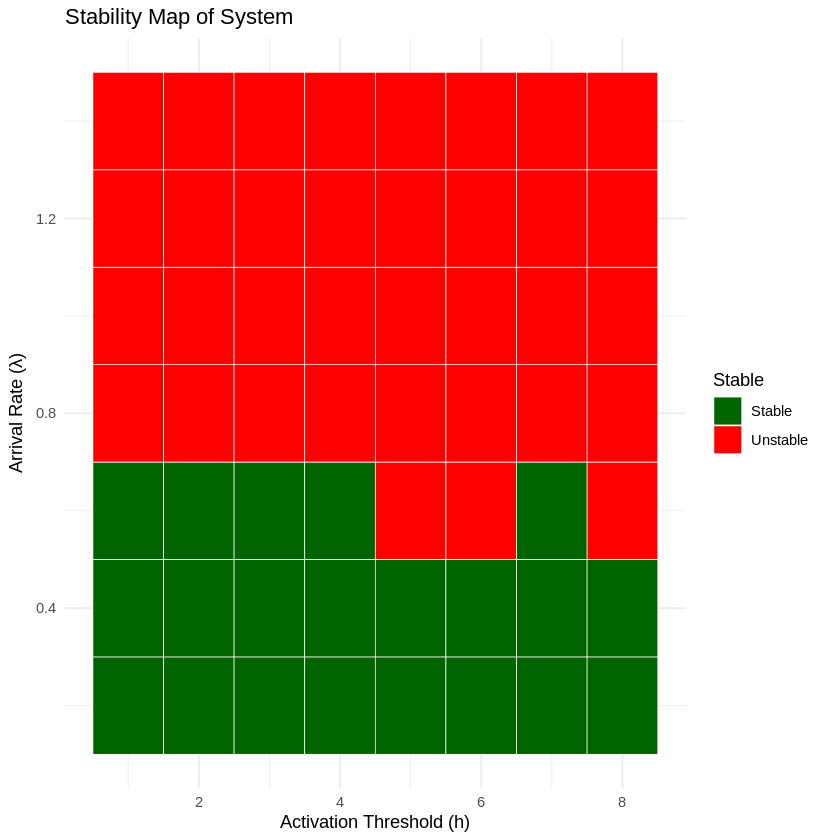

In [17]:
# Phase 7 implementation

lambda_grid <- seq(0.2, 1.4, by = 0.2)
h_grid <- 1:8
num_slots <- 1000
base_servers <- 2

results_2D <- expand.grid(lambda = lambda_grid, h = h_grid)
results_2D$mean_Q <- NA_real_
results_2D$Stable <- NA_character_

for (i in seq_len(nrow(results_2D))) {
  lam <- results_2D$lambda[i]
  h_val <- results_2D$h[i]
  sim_out <- simulate_queue(lambda = lam,
                            num_slots = num_slots,
                            base_servers = base_servers,
                            h = h_val,
                            menu_q = menu_q,
                            menu_p = menu_p)

  Q_series <- sim_out$Q_series
  results_2D$mean_Q[i] <- mean(Q_series)
  results_2D$Stable[i] <- ifelse(mean(Q_series) < 2.4, "Stable", "Unstable")
}

library(ggplot2)

ggplot(results_2D, aes(x = h, y = lambda, fill = mean_Q)) +
  geom_tile(color="white") +
  scale_fill_viridis_c(option="plasma") +
  geom_text(aes(label = sprintf("%.1f", mean_Q)), color="white", size=3) +
  labs(title = "Mean Queue Length across λ–h Grid",
       x = "Activation Threshold (h)", y = "Arrival Rate (λ)",
       fill = "E[Q]") +
  theme_minimal()

ggplot(results_2D, aes(x = h, y = lambda, fill = Stable)) +
  geom_tile(color="white") +
  scale_fill_manual(values=c("Stable"="darkgreen","Unstable"="red")) +
  labs(title = "Stability Map of System",
       x = "Activation Threshold (h)", y = "Arrival Rate (λ)") +
  theme_minimal()
